In [158]:
#!!!!!!!!!!!!! ONLY RUN THIS CODE WHEN YOU DON'T HAVE THE CSV !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

from scipy.io import arff
import pandas as pd

# Load the arff file
data, meta = arff.loadarff('fps-in-video-games.arff')

# Convert to a pandas DataFrame
df = pd.DataFrame(data)
df.to_csv('fps-in-video-games.csv', index=False)

In [159]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt






In [160]:

df = pd.read_csv('fps-in-video-games.csv')
print(df.shape)
df.head()

(425833, 45)


,CpuName,CpuNumberOfCores,CpuNumberOfThreads,CpuBaseClock,CpuCacheL1,CpuCacheL2,CpuCacheL3,CpuDieSize,CpuFrequency,CpuMultiplier,...,GpuNumberOfShadingUnits,GpuNumberOfTMUs,GpuTextureRate,GpuNumberOfTransistors,GpuVulkan,GameName,GameResolution,GameSetting,Dataset,FPS
0,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',70.0
1,b'Intel Core i7-920',4.0,8.0,133.0,256.0,1024.0,8.0,0.000263,2666.0,20.0,...,2304.0,144.0,182300.0,5700.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',230.0
2,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',250.0
3,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,2560.0,160.0,277300.0,7200.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',300.0
4,b'Intel Core i5-4690',4.0,4.0,100.0,256.0,1024.0,6.0,0.000177,3400.0,34.0,...,896.0,56.0,61600.0,2080.0,b'1.2.131',b'counterStrikeGlobalOffensive',1080.0,b'low',b'userbenchmark',200.0


In [161]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  str    
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  str    
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors     199794 non-nu

In [162]:
# Convert byte to string
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.replace("b'", "", regex=False).str.replace("'", "", regex=False)


In [163]:
df = df.rename(columns={"GpuBus nterface": "GpuBusInterface"})

In [164]:
missing = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
GpuNumberOfExecutionUnits,412935,96.971113
GpuNumberOfComputeUnits,357107,83.860809
CpuNumberOfTransistors,226039,53.081607
CpuDieSize,202534,47.561838
GpuBandwidth,15441,3.626069
GpuMemorySize,15441,3.626069
GpuMemoryBus,15441,3.626069
GpuNumberOfTransistors,11539,2.709748
GpuDieSize,11196,2.629200
CpuCacheL3,5055,1.187085


In [165]:
cols_to_drop = missing_percent[missing_percent > 10].index
print("Dropped columns:", cols_to_drop)
df = df.drop(columns=cols_to_drop)

Dropped columns: Index(['CpuDieSize', 'CpuNumberOfTransistors', 'GpuNumberOfComputeUnits',
       'GpuNumberOfExecutionUnits'],
      dtype='str')


In [166]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [167]:
# Drop duplicate
df = df.drop_duplicates()

# Drop kolom yang tidak penting (opsional)
df = df.drop(columns=["CpuName", "GpuName"], errors='ignore')

In [168]:
Q1 = df["FPS"].quantile(0.25)
Q3 = df["FPS"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["FPS"] >= Q1 - 1.5*IQR) & (df["FPS"] <= Q3 + 1.5*IQR)]

In [169]:
# check the spread for game name
print(df["GameName"].value_counts())

# Slicing the dataset to only include games with at less than 10000 samples
df = df[df["GameName"].isin(df["GameName"].value_counts()[df["GameName"].value_counts() < 10000].index)]

GameName
counterStrikeGlobalOffensive    27021
fortnite                        22811
playerUnknownsBattlegrounds     21256
overwatch                       18789
grandTheftAuto5                 17627
leagueOfLegends                 15248
battlefield1                     9681
apexLegends                      8262
dota2                            6783
worldOfTanks                     6541
battlefield4                     5809
minecraft                        4875
callOfDutyBlackOps4              4097
rust                             3119
arkSurvivalEvolved               2915
rocketLeague                     2444
callOfDutyWW2                    1026
pathOfExile                      1026
destiny2                         1026
radicalHeights                   1026
seaOfThieves                     1026
frostpunk                        1026
totalWar3Kingdoms                1026
airMechStrike                    1026
battletech                       1026
farCry5                          1026
sta

In [170]:

le = LabelEncoder()

for col in df.select_dtypes(include=['object','string']).columns:
    df[col] = le.fit_transform(df[col])


In [171]:
X = df.drop("FPS", axis=1)
y = df["FPS"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


print("Before PCA:", X_train_scaled.shape)
print("After PCA :", X_train_pca.shape)

Before PCA: (55110, 38)
After PCA : (55110, 18)


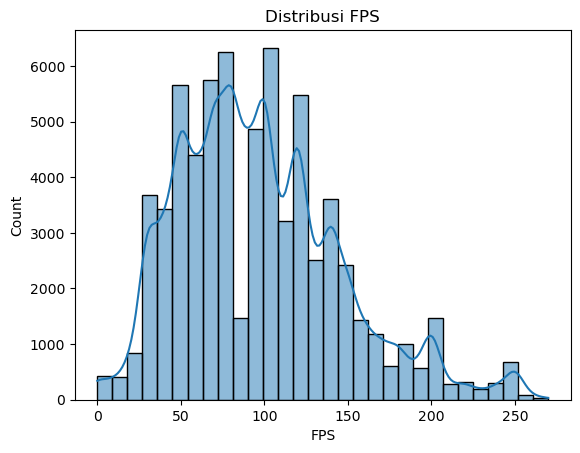

In [172]:
sns.histplot(df["FPS"], bins=30, kde=True)
plt.title("Distribusi FPS")
plt.show()

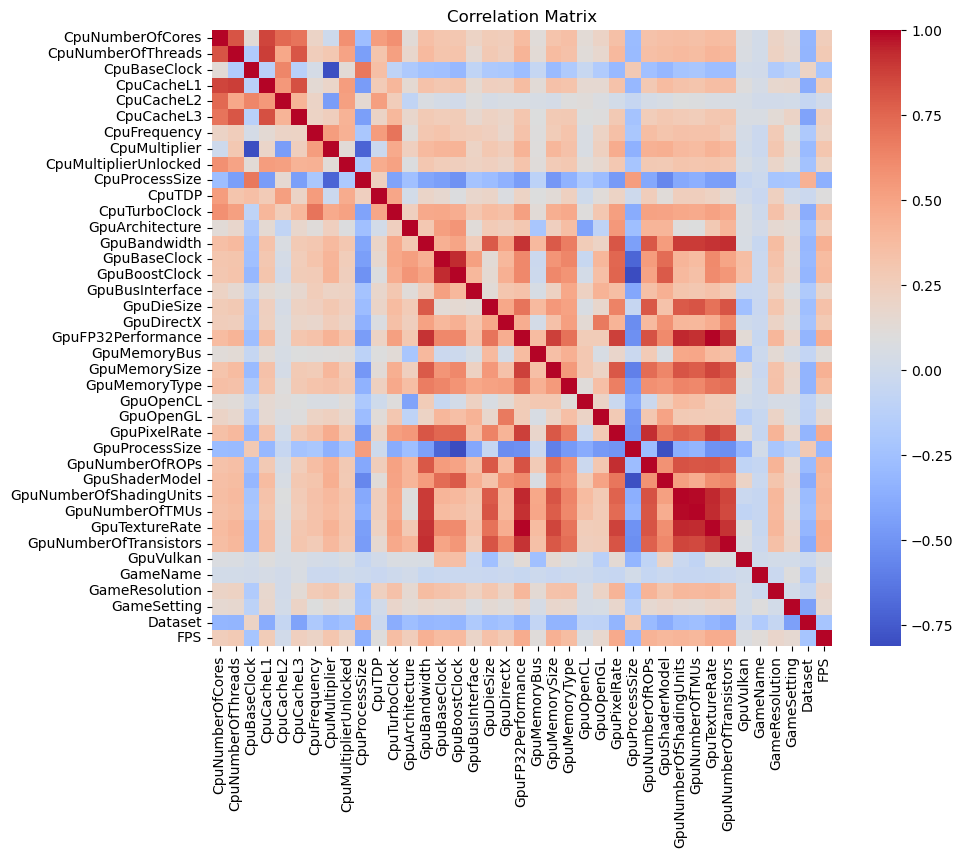

In [173]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

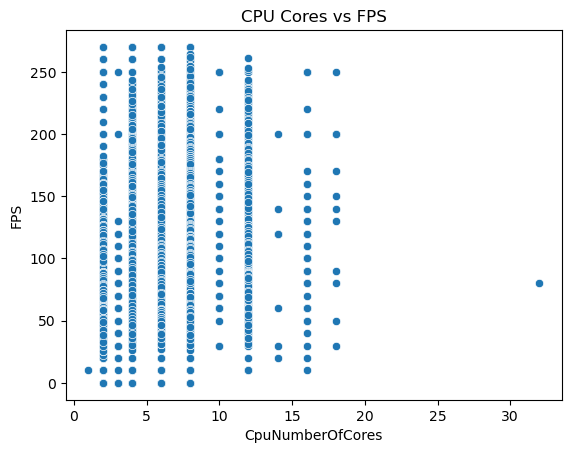

In [174]:
sns.scatterplot(x=df["CpuNumberOfCores"], y=df["FPS"])
plt.title("CPU Cores vs FPS")
plt.show()

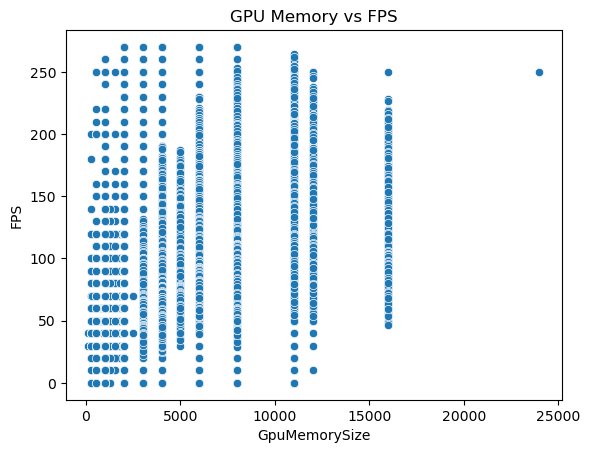

In [175]:
sns.scatterplot(x=df["GpuMemorySize"], y=df["FPS"])
plt.title("GPU Memory vs FPS")
plt.show()

<Axes: xlabel='GameResolution', ylabel='FPS'>

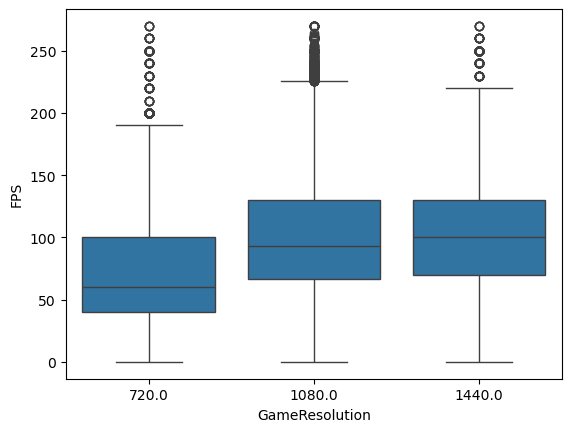

In [176]:
sns.boxplot(x=df["GameResolution"], y=df["FPS"])


In [177]:
def evaluate_model(y_true, y_pred):
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("R2  :", r2_score(y_true, y_pred))

In [178]:
lr = LinearRegression()
lr.fit(X_train_pca, y_train)

y_pred_lr = lr.predict(X_test_pca)


In [179]:

# Input Layer
inputs = keras.Input(shape=(X_train_pca.shape[1],))

# Hidden Layers
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)

# Output Layer
outputs = layers.Dense(1)(x)

# Functional API Model
baseline_model = keras.Model(inputs=inputs, outputs=outputs)

# Compile Model
baseline_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model Summary
print("Baseline ANN Architecture")
baseline_model.summary()

# Train Baseline Model
history_baseline = baseline_model.fit(
    X_train_pca,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict Baseline
y_pred_baseline = baseline_model.predict(X_test_pca)



Baseline ANN Architecture


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2670.2109 - mae: 37.9896 - val_loss: 1732.5573 - val_mae: 31.5150
Epoch 2/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1656.7214 - mae: 30.9058 - val_loss: 1696.9366 - val_mae: 31.1278
Epoch 3/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 1631.1398 - mae: 30.6693 - val_loss: 1684.8445 - val_mae: 31.0218
Epoch 4/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1615.7083 - mae: 30.4987 - val_loss: 1677.0045 - val_mae: 30.8156
Epoch 5/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1603.9642 - mae: 30.3674 - val_loss: 1660.1198 - val_mae: 30.9257
Epoch 6/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1590.5161 - mae: 30.2301 - val_loss: 1650.6450 - val_mae: 30.6168
Epoch 7/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1572.6987 - mae: 30.0295 - val_loss: 1635.0138 - val_mae: 30.5869
Epoch 8/20
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1552.6859 - mae: 29.8265 - val_loss: 1623.

In [180]:

print("Linear Regression")
evaluate_model(y_test, y_pred_lr)
# Evaluate Baseline
print("\nBaseline ANN Performance")
evaluate_model(y_test, y_pred_baseline)



Linear Regression
RMSE: 41.28929443323183
MAE : 31.56841741265276
R2  : 0.2903336621921855

Baseline ANN Performance
RMSE: 37.71153319974753
MAE : 28.900987923794204
R2  : 0.4079918831681121


In [181]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(lr, X_train_pca, y_train, cv=kf, scoring='r2')

print("LR CV R2:", lr_cv.mean())


LR CV R2: 0.2847197099866129


In [182]:
from itertools import product

param_grid = {
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64],
    "num_units": [64, 128],
    "dropout_rate": [0.2, 0.3]
}


def build_model(num_units, dropout_rate, learning_rate):
    inputs = keras.Input(shape=(X_train_pca.shape[1],))

    x = layers.Dense(num_units, activation='relu')(inputs)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(num_units // 2, activation='relu')(x)

    outputs = layers.Dense(1)(x)  # adjust if classification

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse',  # change if classification
        metrics=['mae']
    )

    return model

results = []

for lr, bs, units, dr in product(
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["num_units"],
    param_grid["dropout_rate"]
):

    print(f"Testing: lr={lr}, batch={bs}, units={units}, dropout={dr}")

    model = build_model(units, dr, lr)

    history = model.fit(
        X_train_pca,
        y_train,
        validation_split=0.2,
        epochs=20,   # keep small first
        batch_size=bs,
        verbose=0
    )

    val_loss = min(history.history["val_loss"])

    results.append({
        "lr": lr,
        "batch_size": bs,
        "units": units,
        "dropout": dr,
        "val_loss": val_loss
    })


Testing: lr=0.001, batch=32, units=64, dropout=0.2
Testing: lr=0.001, batch=32, units=64, dropout=0.3
Testing: lr=0.001, batch=32, units=128, dropout=0.2
Testing: lr=0.001, batch=32, units=128, dropout=0.3
Testing: lr=0.001, batch=64, units=64, dropout=0.2
Testing: lr=0.001, batch=64, units=64, dropout=0.3
Testing: lr=0.001, batch=64, units=128, dropout=0.2
Testing: lr=0.001, batch=64, units=128, dropout=0.3
Testing: lr=0.0005, batch=32, units=64, dropout=0.2
Testing: lr=0.0005, batch=32, units=64, dropout=0.3
Testing: lr=0.0005, batch=32, units=128, dropout=0.2
Testing: lr=0.0005, batch=32, units=128, dropout=0.3
Testing: lr=0.0005, batch=64, units=64, dropout=0.2
Testing: lr=0.0005, batch=64, units=64, dropout=0.3
Testing: lr=0.0005, batch=64, units=128, dropout=0.2
Testing: lr=0.0005, batch=64, units=128, dropout=0.3


In [183]:
best_result = min(results, key=lambda x: x["val_loss"])

print("\n✅ Best config:")
print(best_result)

best_model = build_model(
    best_result["units"],
    best_result["dropout"],
    best_result["lr"]
)

best_model.fit(
    X_train_pca,
    y_train,
    epochs=50,
    batch_size=best_result["batch_size"],
    validation_split=0.2,
    verbose=1
)

y_pred_best = best_model.predict(X_test_pca)
print("\nBest ANN Performance")
evaluate_model(y_test, y_pred_best)






✅ Best config:
{'lr': 0.001, 'batch_size': 32, 'units': 128, 'dropout': 0.2, 'val_loss': 1452.1458740234375}
Epoch 1/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2245.5359 - mae: 35.2620 - val_loss: 1723.3073 - val_mae: 31.3467
Epoch 2/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1687.1366 - mae: 31.1062 - val_loss: 1694.7385 - val_mae: 31.0503
Epoch 3/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1659.1503 - mae: 30.8799 - val_loss: 1682.6796 - val_mae: 31.4188
Epoch 4/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1650.7161 - mae: 30.8125 - val_loss: 1674.4771 - val_mae: 31.1653
Epoch 5/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1637.5752 - mae: 30.6370 - val_loss: 1658.6128 - val_mae: 30.4777
Epoch 6/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1619.9265 - mae: 30.4433 - val_loss: 1640.2446 - val_mae: 30.6119
Epoch 7/50
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1599.2850 - mae: 30.2410 - val_loss: 1642.8922 - val_mae: 30

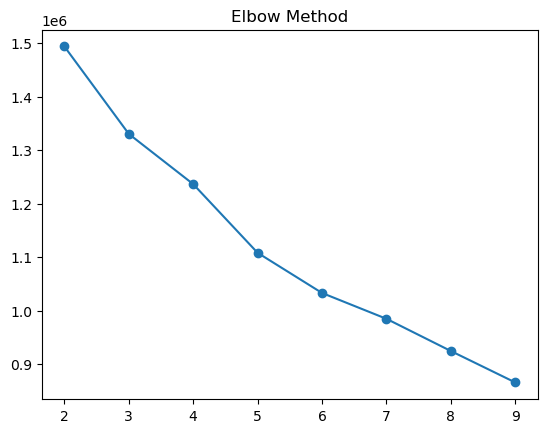

In [184]:
inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

<module 'matplotlib.pyplot' from 'd:\\Users\\bsi80269\\.conda\\envs\\myenv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

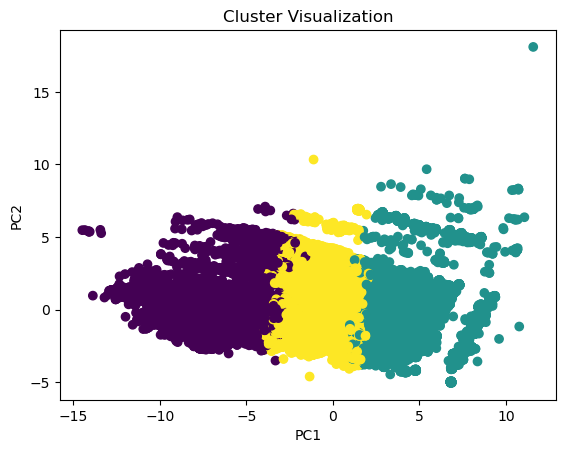

In [185]:

clusters = KMeans(n_clusters=3, random_state=42).fit_predict(X_train_pca)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Visualization")
plt

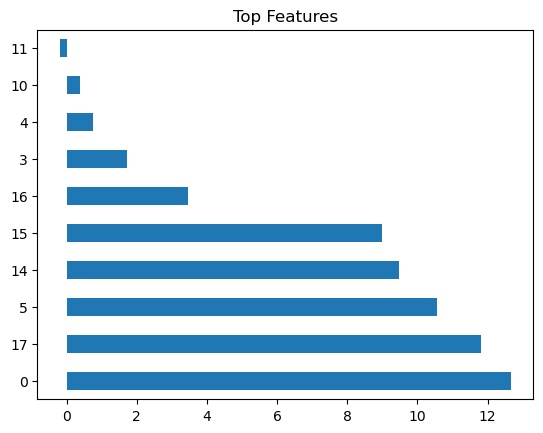

In [188]:
importances = best_model.get_weights()[0].sum(axis=1)

feat_imp = pd.Series(importances).sort_values(ascending=False)

feat_imp[:10].plot(kind='barh')
plt.title("Top Features")
plt.show()
